# Resampling: Upsampling and Downsampling

Two complementary operators change **length**:

- `time_series_upsampling(series, target_length, interpolation_method)` — 1-D input,
  interpolates onto a longer grid (`linear` / `cubic` / `lagrange`).
- `time_series_downsampling(ts_data, ...)` — **2-D** input `[num_samples, seq_length]`.
  Specify `target_length` **or** `scale_factor` in `(0, 1)`. Methods:
  interpolation (`linear`, `cubic`, `lagrange`) or window aggregation (`mean`, `max`, `min`).

`lagrange` is only stable for **short** series (Runge phenomenon). The sweeps below
use linear / cubic / mean for the 512-step traces, and a short crop for Lagrange.


In [1]:
%matplotlib inline
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(os.path.join("..", "..")))

from s2generator.utils import (
    load_univariate,
    generate_arma_samples,
    generate_nonstationary_sine,
    generate_chirp_signal,
)

L = 512
rng = np.random.RandomState(0)
np.random.seed(0)

synth = np.asarray(generate_arma_samples(L), dtype=float)
real = load_univariate("ETTh1")[:L].astype(float)


def overlay_pair(originals, variants, titles, ylabel="value"):
    # Plot original vs augmented traces for synth (left) and real (right).
    n = len(titles)
    fig, axes = plt.subplots(
        n, 2, figsize=(11.5, 2.55 * n), sharex=False, squeeze=False
    )
    col_titles = ["synthetic (ARMA)", "real (ETTh1 OT)"]
    for col, (orig, var_list) in enumerate(zip(originals, variants)):
        for row, (label, series) in enumerate(var_list):
            ax = axes[row, col]
            ax.plot(orig, color="0.55", lw=1.15, label="original")
            ax.plot(series, color="C0", lw=1.15, alpha=0.9, label=label)
            if row == 0:
                ax.set_title(col_titles[col], fontweight="bold")
            if col == 0:
                ax.set_ylabel(ylabel)
            ax.legend(fontsize=8, loc="upper right", frameon=False)
            ax.grid(True, alpha=0.3)
            axes[row, 0].set_ylabel(titles[row], fontsize=10)
    axes[-1, 0].set_xlabel("t")
    axes[-1, 1].set_xlabel("t")
    fig.tight_layout()
    return fig


def sweep_grid(series_list, names, makers, param_title):
    # makers: list of (label, fn) applied to each series.
    n_s, n_p = len(series_list), len(makers)
    fig, axes = plt.subplots(n_s, n_p, figsize=(3.6 * n_p, 2.5 * n_s), squeeze=False)
    for i, (series, name) in enumerate(zip(series_list, names)):
        for j, (label, fn) in enumerate(makers):
            ax = axes[i, j]
            ax.plot(series, color="0.55", lw=1.0, label="original")
            ax.plot(fn(series), color="C3", lw=1.05, alpha=0.9, label=label)
            if i == 0:
                ax.set_title(label, fontsize=10)
            if j == 0:
                ax.set_ylabel(name)
            ax.grid(True, alpha=0.3)
            if i == 0 and j == n_p - 1:
                ax.legend(fontsize=7, loc="upper right", frameon=False)
    fig.suptitle(param_title, y=1.02, fontweight="bold")
    fig.tight_layout()
    return fig


from s2generator.augmentation import time_series_upsampling, time_series_downsampling

## Upsampling synthetic and real series (512 -> 768)


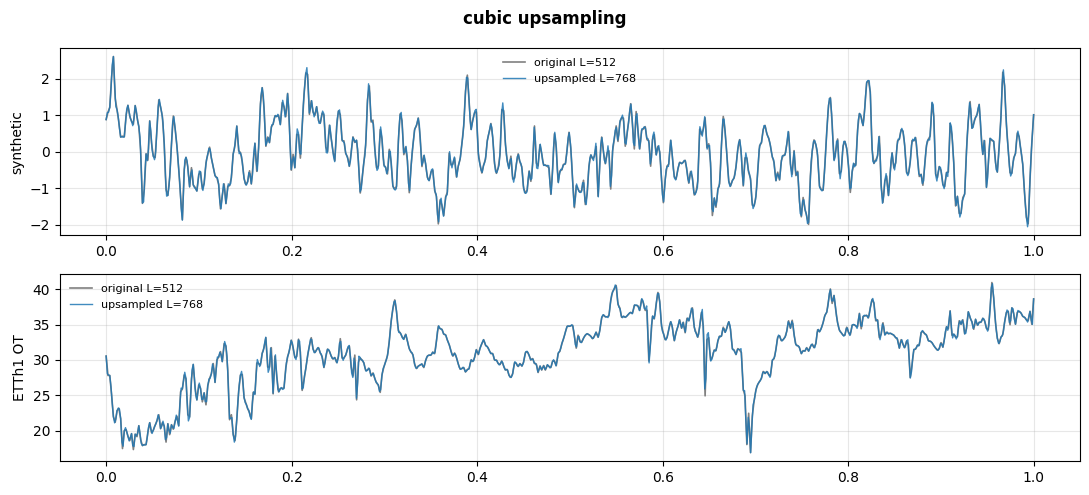

lengths 512 -> 768 | 512 -> 768


In [2]:
up_s = time_series_upsampling(synth, target_length=768, interpolation_method="cubic")
up_r = time_series_upsampling(real, target_length=768, interpolation_method="cubic")

fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=False)
for ax, orig, up, name in [
    (axes[0], synth, up_s, "synthetic"),
    (axes[1], real, up_r, "ETTh1 OT"),
]:
    t0 = np.linspace(0, 1, len(orig))
    t1 = np.linspace(0, 1, len(up))
    ax.plot(t0, orig, color="0.5", lw=1.2, label="original L=%d" % len(orig))
    ax.plot(t1, up, color="C0", lw=1.0, alpha=0.85, label="upsampled L=%d" % len(up))
    ax.set_ylabel(name)
    ax.legend(fontsize=8, frameon=False)
    ax.grid(True, alpha=0.3)
fig.suptitle("cubic upsampling", fontweight="bold")
fig.tight_layout()
plt.show()
print("lengths", len(synth), "->", len(up_s), "|", len(real), "->", len(up_r))

## Downsampling methods (512 -> 128)

`mean` aggregation is a low-pass anti-alias; `max` keeps peaks; cubic interpolation
follows the curve more tightly but can ring.


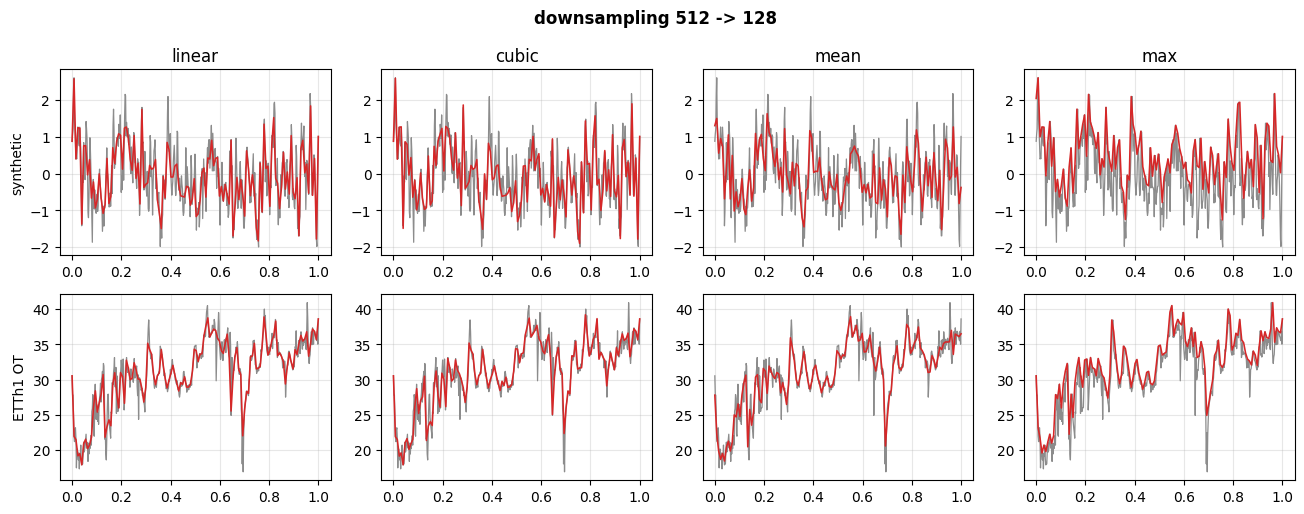

In [3]:
target = 128
methods = ["linear", "cubic", "mean", "max"]
fig, axes = plt.subplots(
    2, len(methods), figsize=(3.3 * len(methods), 5.2), sharey=False
)
for row, (series, name) in enumerate([(synth, "synthetic"), (real, "ETTh1 OT")]):
    t0 = np.linspace(0, 1, len(series))
    for col, method in enumerate(methods):
        ax = axes[row, col]
        down = time_series_downsampling(
            series[None, :], target_length=target, method=method
        )[0]
        t1 = np.linspace(0, 1, len(down))
        ax.plot(t0, series, color="0.55", lw=0.9)
        ax.plot(t1, down, color="C3", lw=1.15)
        if row == 0:
            ax.set_title(method)
        if col == 0:
            ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
fig.suptitle("downsampling 512 -> 128", fontweight="bold")
fig.tight_layout()
plt.show()

## Parameter: scale_factor and interpolation on a short crop (Lagrange)

On 48 samples, Lagrange is usable. `scale_factor=0.5` halves the length.


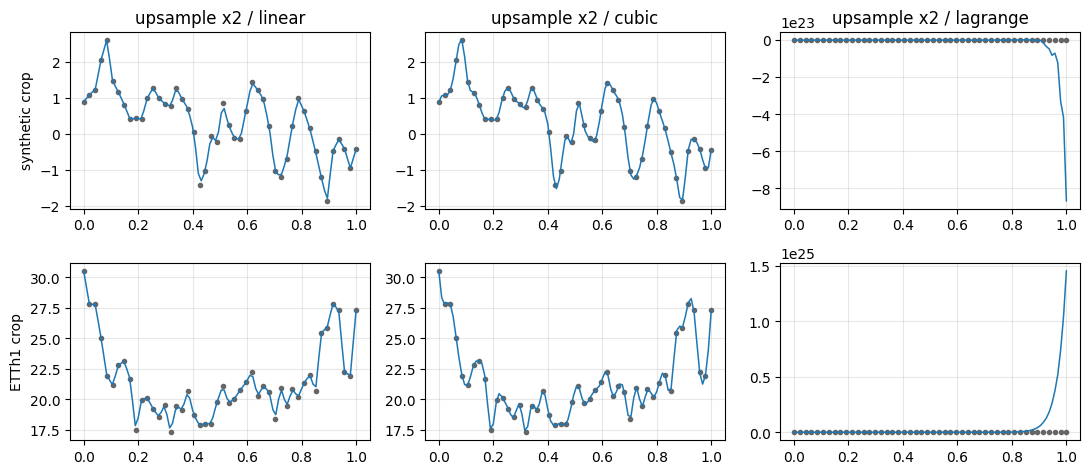

scale_factor=0.5 -> (1, 256)


In [4]:
crop_s, crop_r = synth[:48], real[:48]
fig, axes = plt.subplots(2, 3, figsize=(11, 5))
for row, (series, name) in enumerate(
    [(crop_s, "synthetic crop"), (crop_r, "ETTh1 crop")]
):
    t0 = np.linspace(0, 1, len(series))
    for col, method in enumerate(["linear", "cubic", "lagrange"]):
        ax = axes[row, col]
        up = time_series_upsampling(
            series, target_length=96, interpolation_method=method
        )
        t1 = np.linspace(0, 1, len(up))
        ax.plot(t0, series, "o", color="0.4", ms=3, label="knots")
        ax.plot(t1, up, color="C0", lw=1.1, label=method)
        if row == 0:
            ax.set_title("upsample x2 / " + method)
        if col == 0:
            ax.set_ylabel(name)
        ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

down_half = time_series_downsampling(synth[None, :], scale_factor=0.5, method="mean")
print("scale_factor=0.5 ->", down_half.shape)